In [6]:
import zipfile, io, os, json, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix
)

In [12]:
warnings.filterwarnings('ignore')

# ── Configuración del experimento (MODIFICADA) ────────────────────────
ZIP_PATH   = 'data\harth\harth.zip'      
FS         = 50               # Hz
WINDOW_SEC = 2                # CAMBIO: 2 segundos por ventana (antes 3)
OVERLAP    = 0.5              # 50% solapamiento
WINDOW_LEN = int(FS * WINDOW_SEC)            # 100 muestras
STEP       = int(WINDOW_LEN * (1 - OVERLAP)) # 50 muestras

# Hiperparámetros de entrenamiento
EPOCHS      = 50
BATCH_SIZE  = 128
LR          = 3e-4
PATIENCE    = 10
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

# 12 actividades originales de HARTH
ACTIVITY_LABELS = {
    1:  'walking',           2:  'running',
    3:  'shuffling',         4:  'stairs_up',
    5:  'stairs_down',       6:  'standing',
    7:  'sitting',           8:  'lying',
    13: 'cycling_sit',       14: 'cycling_stand',
    130:'cycling_sit_inact', 140:'cycling_st_inact',
}
LABEL_TO_IDX = {v: i for i, v in enumerate(ACTIVITY_LABELS.values())}
CODE_TO_IDX  = {k: LABEL_TO_IDX[v] for k, v in ACTIVITY_LABELS.items()}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}
N_CLASSES    = len(ACTIVITY_LABELS)
SENSOR_COLS  = ['back_x','back_y','back_z','thigh_x','thigh_y','thigh_z']

# Colores por modelo para gráficos
MODEL_COLORS = {
    'svm':       '#E15759',
    'cnn1d':     '#4E79A7',
    'cnn_bilstm':'#59A14F',
    'cnn_gru':   '#F28E2B',
}
MODEL_LABELS = {
    'svm':       'SVM (baseline)',
    'cnn1d':     'CNN 1D',
    'cnn_bilstm':'CNN + BiLSTM (propuesto)',
    'cnn_gru':   'CNN + GRU',
}

print(f'Dispositivo: {DEVICE}')
print(f'Ventana: {WINDOW_LEN} muestras ({WINDOW_SEC}s) | Paso: {STEP} muestras')
print(f'Clases: {N_CLASSES}')

Dispositivo: cuda
Ventana: 100 muestras (2s) | Paso: 50 muestras
Clases: 12


In [13]:
def load_harth_from_zip(zip_path):
    """
    Lee todos los CSV de sujetos desde el ZIP.
    Retorna dict {subject_id: DataFrame}.
    """
    subjects = {}
    with zipfile.ZipFile(zip_path, 'r') as zf:
        csv_files = sorted([f for f in zf.namelist() if f.endswith('.csv')])
        print(f'Archivos CSV en el ZIP: {len(csv_files)}')
        for fname in csv_files:
            subj_id = Path(fname).stem  # 'S006', 'S008', ...
            with zf.open(fname) as f:
                df = pd.read_csv(io.TextIOWrapper(f, encoding='utf-8'))
            df.columns = [c.strip().lower() for c in df.columns]
            df = df[df['label'].isin(CODE_TO_IDX.keys())].copy()
            df['label_idx'] = df['label'].map(CODE_TO_IDX)
            subjects[subj_id] = df
    return subjects

subjects = load_harth_from_zip(ZIP_PATH)

print(f'\nSujetos cargados: {len(subjects)}')
for sid, df in subjects.items():
    print(f'  {sid}: {len(df):>7,} filas | actividades: {sorted(df["label_idx"].unique())}')

Archivos CSV en el ZIP: 22

Sujetos cargados: 22
  S006: 408,709 filas | actividades: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  S008: 418,989 filas | actividades: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
  S009: 154,464 filas | actividades: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
  S010: 351,649 filas | actividades: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  S012: 382,414 filas | actividades: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  S013: 369,077 filas | actividades: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]
  S014: 366,487 filas | acti

Total muestras : 6,461,328  (35.90 horas a 50 Hz)
Total sujetos  : 22

Distribución de clases:
  [ 0] walking                 1,197,155  ( 18.5%)
  [ 1] running                  291,356  (  4.5%)
  [ 2] shuffling                254,839  (  3.9%)
  [ 3] stairs_up                 76,217  (  1.2%)
  [ 4] stairs_down               67,253  (  1.0%)
  [ 5] standing                 743,480  ( 11.5%)
  [ 6] sitting                 2,902,703  ( 44.9%)
  [ 7] lying                    428,898  (  6.6%)
  [ 8] cycling_sit              393,963  (  6.1%)
  [ 9] cycling_stand             55,814  (  0.9%)
  [10] cycling_sit_inact         41,785  (  0.6%)
  [11] cycling_st_inact           7,865  (  0.1%)


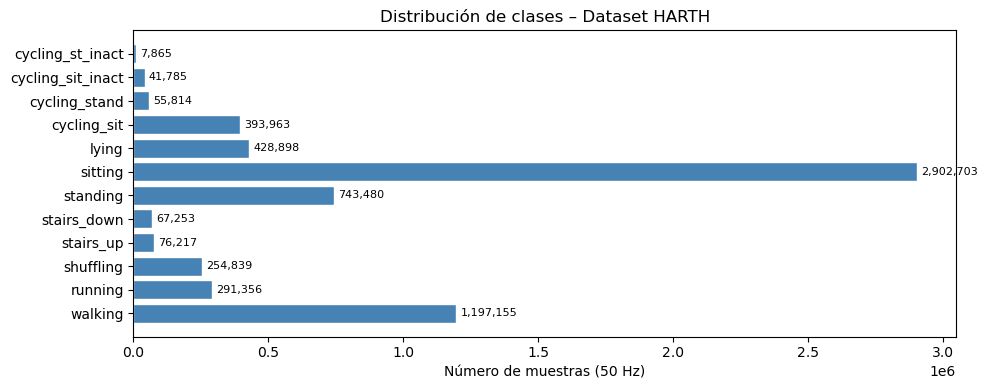

In [14]:
# Distribución global de clases
all_labels = []
for df in subjects.values():
    all_labels.extend(df['label_idx'].tolist())
counter = Counter(all_labels)
total   = len(all_labels)

print(f'Total muestras : {total:,}  ({total/FS/3600:.2f} horas a {FS} Hz)')
print(f'Total sujetos  : {len(subjects)}')
print('\nDistribución de clases:')
for idx in range(N_CLASSES):
    name  = IDX_TO_LABEL[idx]
    count = counter.get(idx, 0)
    print(f'  [{idx:2d}] {name:<22}  {count:>8,}  ({100*count/total:5.1f}%)')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
names  = [IDX_TO_LABEL[i] for i in range(N_CLASSES)]
counts = [counter.get(i, 0) for i in range(N_CLASSES)]
bars = ax.barh(names, counts, color='steelblue', edgecolor='white')
ax.set_xlabel('Número de muestras (50 Hz)')
ax.set_title('Distribución de clases – Dataset HARTH')
ax.bar_label(bars, labels=[f'{c:,}' for c in counts], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

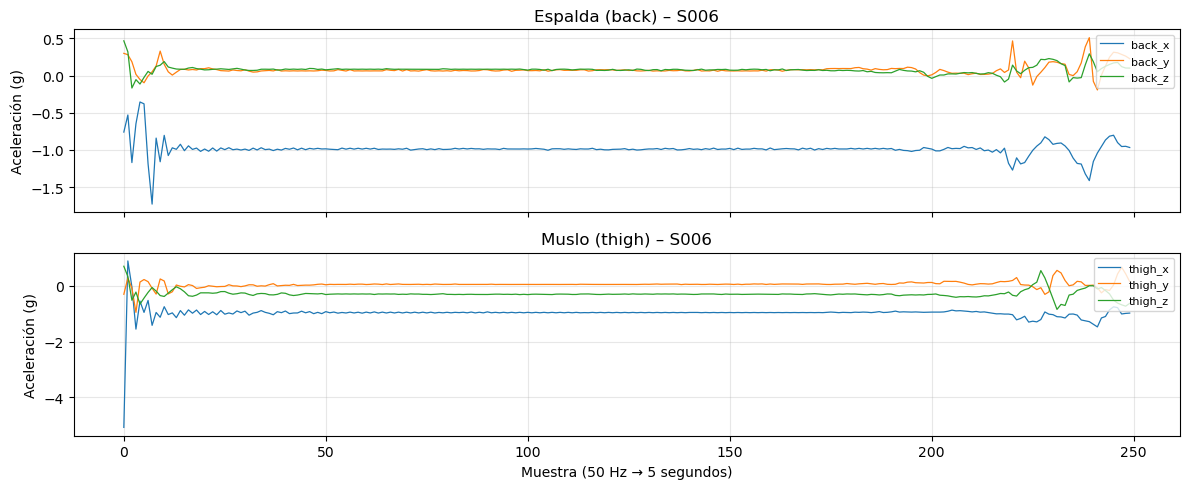

In [15]:
# Muestra 5 segundos de señal para el primer sujeto
sid_example = list(subjects.keys())[0]
df_ex = subjects[sid_example].iloc[:250]  # 5s a 50Hz

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

for i, (label, cols) in enumerate([
    ('Espalda (back)',  ['back_x',  'back_y',  'back_z']),
    ('Muslo (thigh)',   ['thigh_x', 'thigh_y', 'thigh_z']),
]):
    for col in cols:
        axes[i].plot(df_ex[col].values, label=col, linewidth=0.9)
    axes[i].set_ylabel('Aceleración (g)')
    axes[i].set_title(f'{label} – {sid_example}')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].grid(alpha=0.3)

axes[1].set_xlabel('Muestra (50 Hz → 5 segundos)')
plt.tight_layout()
plt.show()

In [16]:
def segment_subject(df):
    """Segmenta un sujeto en ventanas. CAMBIO: Etiqueta = centro temporal de la ventana."""
    data   = df[SENSOR_COLS].values.astype(np.float32)
    labels = df['label_idx'].values
    X_list, y_list = [], []
    
    for start in range(0, len(data) - WINDOW_LEN + 1, STEP):
        end     = start + WINDOW_LEN
        window  = data[start:end]       # (100, 6)
        
        # CAMBIO: Tomar la etiqueta de la muestra que está justo en el medio
        center_idx = start + (WINDOW_LEN // 2)
        center_label = labels[center_idx]
        
        X_list.append(window)
        y_list.append(center_label)
        
    if not X_list:
        return np.empty((0, WINDOW_LEN, 6), np.float32), np.empty((0,), np.int64)
    return np.array(X_list, np.float32), np.array(y_list, np.int64)

# Segmentar todos los sujetos
dataset = {}
total_windows = 0
for sid, df in subjects.items():
    X, y = segment_subject(df)
    dataset[sid] = (X, y)
    total_windows += len(X)
    print(f'  {sid}: {X.shape[0]:>5} ventanas | X={X.shape} | clases: {np.unique(y)}')

print(f'\nTotal ventanas: {total_windows:,}')
print(f'Forma de una ventana: {X.shape[1:]}  (muestras × canales)')

  S006:  8173 ventanas | X=(8173, 100, 6) | clases: [ 0  2  3  4  5  6  7  8  9 10]
  S008:  8378 ventanas | X=(8378, 100, 6) | clases: [ 0  2  3  4  5  6  8  9 10 11]
  S009:  3088 ventanas | X=(3088, 100, 6) | clases: [ 0  2  3  4  5  8  9 10 11]
  S010:  7031 ventanas | X=(7031, 100, 6) | clases: [0 2 3 4 5 6]
  S012:  7647 ventanas | X=(7647, 100, 6) | clases: [0 1 2 3 4 5 6 7]
  S013:  7380 ventanas | X=(7380, 100, 6) | clases: [ 0  1  2  3  4  5  6  7  8 10]
  S014:  7328 ventanas | X=(7328, 100, 6) | clases: [0 1 2 3 4 5 6 7 8]
  S015:  8366 ventanas | X=(8366, 100, 6) | clases: [0 1 2 3 4 5 6 7 8 9]
  S016:  7107 ventanas | X=(7107, 100, 6) | clases: [ 0  1  2  3  4  5  6  7  8  9 10]
  S017:  7331 ventanas | X=(7331, 100, 6) | clases: [ 0  1  2  3  4  5  6  7  8  9 10 11]
  S018:  6444 ventanas | X=(6444, 100, 6) | clases: [ 0  1  2  3  4  5  6  7  8  9 10]
  S019:  5957 ventanas | X=(5957, 100, 6) | clases: [ 0  1  2  3  4  5  6  7  8  9 10]
  S020:  7428 ventanas | X=(7428, 

In [17]:
def normalize_fold(dataset, test_sid):
    """CAMBIO: Escalado Min-Max al rango [-1, 1] calculado SOLO en train."""
    X_all = np.concatenate(
        [X for sid, (X, _) in dataset.items() if sid != test_sid], axis=0
    ).reshape(-1, 6)
    
    # Calcular mínimos y máximos por canal en los datos de entrenamiento
    x_min = X_all.min(axis=0, keepdims=True)     # (1, 6)
    x_max = X_all.max(axis=0, keepdims=True)     # (1, 6)
    
    # Prevenir división por 0 en caso de canales constantes
    scale_range = x_max - x_min
    scale_range[scale_range == 0] = 1e-8
    
    # Fórmula MinMax para rango [-1, 1]: 2 * ((X - X_min) / (X_max - X_min)) - 1
    norm = {}
    for sid, (X, y) in dataset.items():
        X_scaled = 2.0 * ((X - x_min) / scale_range) - 1.0
        norm[sid] = (X_scaled, y)
        
    return norm, x_min, x_max

def compute_class_weights(y_train):
    counts  = np.bincount(y_train, minlength=N_CLASSES).astype(np.float32)
    weights = y_train.shape[0] / (N_CLASSES * np.where(counts == 0, 1, counts))
    return torch.tensor(weights, dtype=torch.float32)

# Verificación rápida con el primer sujeto de prueba
_s0 = list(dataset.keys())[0]
_nd, _m, _s = normalize_fold(dataset, _s0)
print('Ejemplo normalización Min-Max (primer fold):')
print(f'  Min  por canal: {_m.flatten().round(4)}')
print(f'  Max  por canal: {_s.flatten().round(4)}')

_yt = np.concatenate([y for sid, (_, y) in _nd.items() if sid != _s0])
cw  = compute_class_weights(_yt)
print(f'\nPesos de clase (entrenamiento sin {_s0}):')
for i, (w, name) in enumerate(zip(cw.tolist(), IDX_TO_LABEL.values())):
    print(f'  [{i:2d}] {name:<22}  {w:.3f}')

Ejemplo normalización Min-Max (primer fold):
  Min  por canal: [-8.     -4.3076 -6.5745 -8.     -7.9973 -8.    ]
  Max  por canal: [2.2917 6.4919 4.9095 7.9998 7.9998 8.4062]

Pesos de clase (entrenamiento sin S006):
  [ 0] walking                 0.429
  [ 1] running                 1.731
  [ 2] shuffling               2.095
  [ 3] stairs_up               6.750
  [ 4] stairs_down             7.704
  [ 5] standing                0.743
  [ 6] sitting                 0.190
  [ 7] lying                   1.213
  [ 8] cycling_sit             1.368
  [ 9] cycling_stand           9.596
  [10] cycling_sit_inact       16.452
  [11] cycling_st_inact        63.031


In [18]:
def extract_features(X):
    """
    Extrae features estadísticos de cada ventana para el SVM.
    X: (N, window_len, 6)  →  devuelve (N, n_features)
    """
    N, T, C = X.shape
    feats = []
    for i in range(N):
        win = X[i]  # (T, C)
        f = []
        for c in range(C):
            sig = win[:, c]
            f += [
                sig.mean(), sig.std(), sig.min(), sig.max(),
                sig.max() - sig.min(),
                float(np.median(sig)),
                float(np.percentile(sig, 25)),
                float(np.percentile(sig, 75)),
                float(np.sum(sig**2) / T),
                float(np.sqrt(np.mean(sig**2))),
                float(np.sum(np.diff(np.sign(sig)) != 0) / T),
                # autocorr lag-1: NaN si varianza=0 (señal constante), reemplazamos con 0
                float(np.corrcoef(sig[:-1], sig[1:])[0, 1]) if sig.std() > 1e-8 else 0.0,
            ]
        # Magnitud vectorial back y thigh
        for sl in [slice(0, 3), slice(3, 6)]:
            mag = np.sqrt((win[:, sl]**2).sum(axis=1))
            f += [mag.mean(), mag.std(), float(np.sqrt(np.mean(mag**2)))]
        # Correlación cruzada back–thigh por canal
        for c in range(3):
            s1, s2 = win[:, c], win[:, c+3]
            if s1.std() > 1e-8 and s2.std() > 1e-8:
                corr = float(np.corrcoef(s1, s2)[0, 1])
            else:
                corr = 0.0
            f.append(corr)
        feats.append(f)

    arr = np.array(feats, dtype=np.float32)
    # Limpieza defensiva: reemplazar cualquier NaN/Inf residual
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr

# Smoke-test
_X_s = dataset[_s0][0][:5]
_feat = extract_features(_X_s)
print(f'Features por ventana: {_feat.shape[1]}')
print(f'NaNs: {np.isnan(_feat).sum()} | Infs: {np.isinf(_feat).sum()}')
print(f'Ejemplo (primera ventana): {_feat[0][:10].round(4)} ...')

Features por ventana: 81
NaNs: 0 | Infs: 0
Ejemplo (primera ventana): [-0.976   0.1365 -1.7302 -0.3551  1.3752 -0.9884 -0.995  -0.9791  0.9712
  0.9855] ...


In [19]:
# ─── Focal Loss ─────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


# ─── CNN 1D base ─────────────────────────────────────────────────
class CNN1D(nn.Module):
    """Red convolucional 1D. Entrada: (B, T, C)"""
    def __init__(self, n_ch=6, T=150, n_cls=12, drop=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_ch, 64,  7, padding=3), nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(64,  128, 5, padding=2), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, 3, padding=1), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(drop),
            nn.AdaptiveAvgPool1d(8),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(256*8, 256), nn.GELU(), nn.Dropout(drop), nn.Linear(256, n_cls)
        )
    def forward(self, x):
        return self.head(self.conv(x.permute(0, 2, 1)))


# ─── CNN 1D + BiLSTM con atención (modelo propuesto) ─────────────
class CNN1D_BiLSTM(nn.Module):
    def __init__(self, n_ch=6, T=150, n_cls=12, hid=128, layers=2, drop=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_ch, 64,  7, padding=3), nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(64,  128, 5, padding=2), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 3, padding=1), nn.BatchNorm1d(128), nn.GELU(),
        )
        self.rnn     = nn.LSTM(128, hid, layers, batch_first=True, bidirectional=True,
                               dropout=drop if layers > 1 else 0.0)
        self.attn_fc = nn.Linear(hid*2, 1)
        self.head    = nn.Sequential(nn.Linear(hid*2, 256), nn.GELU(), nn.Dropout(drop), nn.Linear(256, n_cls))

    def forward(self, x):
        x = self.cnn(x.permute(0,2,1)).permute(0,2,1)
        out, _ = self.rnn(x)
        ctx = (torch.softmax(self.attn_fc(out), dim=1) * out).sum(dim=1)
        return self.head(ctx)


# ─── CNN 1D + GRU con atención (variante) ────────────────────────
class CNN1D_GRU(nn.Module):
    def __init__(self, n_ch=6, T=150, n_cls=12, hid=128, layers=2, drop=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_ch, 64,  7, padding=3), nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(64,  128, 5, padding=2), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 3, padding=1), nn.BatchNorm1d(128), nn.GELU(),
        )
        self.rnn     = nn.GRU(128, hid, layers, batch_first=True, bidirectional=True,
                              dropout=drop if layers > 1 else 0.0)
        self.attn_fc = nn.Linear(hid*2, 1)
        self.head    = nn.Sequential(nn.Linear(hid*2, 256), nn.GELU(), nn.Dropout(drop), nn.Linear(256, n_cls))

    def forward(self, x):
        x = self.cnn(x.permute(0,2,1)).permute(0,2,1)
        out, _ = self.rnn(x)
        ctx = (torch.softmax(self.attn_fc(out), dim=1) * out).sum(dim=1)
        return self.head(ctx)


# ─── Smoke-test de dimensiones ───────────────────────────────────
x_test = torch.randn(4, WINDOW_LEN, 6)
for name, cls in [('CNN1D', CNN1D), ('CNN1D_BiLSTM', CNN1D_BiLSTM), ('CNN1D_GRU', CNN1D_GRU)]:
    m = cls()
    out = m(x_test)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name:<16}  salida={tuple(out.shape)}  parámetros={params:,}')

CNN1D             salida=(4, 12)  parámetros=670,924
CNN1D_BiLSTM      salida=(4, 12)  parámetros=822,349
CNN1D_GRU         salida=(4, 12)  parámetros=657,485


In [20]:
def train_neural_fold(ModelClass, dataset, test_sid, verbose=True):
    """
    Entrena ModelClass en todos los sujetos excepto test_sid,
    evalúa en test_sid. Retorna (y_true, y_pred, historial_loss).
    """
    norm_ds, _, _ = normalize_fold(dataset, test_sid)

    X_test, y_test = norm_ds[test_sid]
    X_tr = np.concatenate([X for s,(X,_) in norm_ds.items() if s != test_sid])
    y_tr = np.concatenate([y for s,(_,y) in norm_ds.items() if s != test_sid])

    cw = compute_class_weights(y_tr).to(DEVICE)

    tr_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=True
    )
    te_loader = DataLoader(
        TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long)),
        batch_size=BATCH_SIZE*4
    )

    model     = ModelClass().to(DEVICE)
    criterion = FocalLoss(gamma=2.0, weight=cw)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_f1, patience_cnt, best_state = 0.0, 0, None
    loss_history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        ep_loss = 0.0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
        scheduler.step()
        avg_loss = ep_loss / len(tr_loader)
        loss_history.append(avg_loss)

        if epoch % 5 == 0:
            model.eval()
            preds = []
            with torch.no_grad():
                for Xb, _ in te_loader:
                    preds.append(model(Xb.to(DEVICE)).argmax(1).cpu())
            val_f1 = f1_score(y_test, torch.cat(preds).numpy(),
                              average='macro', zero_division=0)
            if val_f1 > best_f1:
                best_f1     = val_f1
                patience_cnt = 0
                best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                patience_cnt += 1
                if patience_cnt >= PATIENCE // 5:
                    if verbose:
                        print(f'      Early stop epoch={epoch} best_f1={best_f1:.4f}')
                    break
            if verbose and epoch % 10 == 0:
                print(f'      epoch {epoch:3d}  loss={avg_loss:.4f}  val_f1={val_f1:.4f}')

    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    preds = []
    with torch.no_grad():
        for Xb, _ in te_loader:
            preds.append(model(Xb.to(DEVICE)).argmax(1).cpu())
    return y_test, torch.cat(preds).numpy(), loss_history


def train_svm_fold(dataset, test_sid):
    norm_ds, _, _ = normalize_fold(dataset, test_sid)
    X_test, y_test = norm_ds[test_sid]
    X_tr = np.concatenate([X for s,(X,_) in norm_ds.items() if s != test_sid])
    y_tr = np.concatenate([y for s,(_,y) in norm_ds.items() if s != test_sid])
    print(f'      Extrayendo features...')
    Xf_tr = extract_features(X_tr)
    Xf_te = extract_features(X_test)
    svm = Pipeline([('sc', StandardScaler()),
                    ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                               class_weight='balanced', random_state=42))])
    print(f'      Entrenando SVM ({Xf_tr.shape[0]:,} ventanas, {Xf_tr.shape[1]} features)...')
    svm.fit(Xf_tr, y_tr)
    return y_test, svm.predict(Xf_te)


def compute_metrics(y_true, y_pred):
    return {
        'accuracy':    float(accuracy_score(y_true, y_pred)),
        'f1_macro':    float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
        'f1_weighted': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'precision':   float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall':      float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'f1_per_class':f1_score(y_true, y_pred, average=None,
                                labels=list(range(N_CLASSES)), zero_division=0).tolist(),
        'conf_matrix': confusion_matrix(y_true, y_pred,
                                        labels=list(range(N_CLASSES))).tolist(),
    }

print('✅ Funciones de entrenamiento definidas.')

✅ Funciones de entrenamiento definidas.


In [21]:
subjects_list = list(dataset.keys())
results_svm   = {'per_subject': [], 'y_true_all': [], 'y_pred_all': []}

for i, test_sid in enumerate(subjects_list, 1):
    t0 = time.time()
    print(f'[{i:2d}/{len(subjects_list)}] Test sujeto: {test_sid}')
    y_true, y_pred = train_svm_fold(dataset, test_sid)
    m = compute_metrics(y_true, y_pred)
    m['subject'] = test_sid
    m['time_s']  = round(time.time() - t0, 1)
    results_svm['per_subject'].append(m)
    results_svm['y_true_all'].extend(y_true.tolist())
    results_svm['y_pred_all'].extend(y_pred.tolist())
    print(f'      ✓  F1-macro={m["f1_macro"]:.4f}  Acc={m["accuracy"]:.4f}  ({m["time_s"]}s)\n')

results_svm['mean_f1_macro']  = float(np.mean([r['f1_macro']  for r in results_svm['per_subject']]))
results_svm['std_f1_macro']   = float(np.std( [r['f1_macro']  for r in results_svm['per_subject']]))
results_svm['mean_accuracy']  = float(np.mean([r['accuracy']  for r in results_svm['per_subject']]))
results_svm['mean_precision'] = float(np.mean([r['precision'] for r in results_svm['per_subject']]))
results_svm['mean_recall']    = float(np.mean([r['recall']    for r in results_svm['per_subject']]))
results_svm['global_metrics'] = compute_metrics(
    np.array(results_svm['y_true_all']),
    np.array(results_svm['y_pred_all'])
)

print('\n' + '='*50)
print('SVM – RESULTADOS FINALES')
print(f"  F1-macro : {results_svm['mean_f1_macro']:.4f} ± {results_svm['std_f1_macro']:.4f}")
print(f"  Accuracy : {results_svm['mean_accuracy']:.4f}")
print(f"  Precision: {results_svm['mean_precision']:.4f}")
print(f"  Recall   : {results_svm['mean_recall']:.4f}")

[ 1/22] Test sujeto: S006
      Extrayendo features...
      Entrenando SVM (121,019 ventanas, 81 features)...
      ✓  F1-macro=0.5437  Acc=0.8913  (551.0s)

[ 2/22] Test sujeto: S008
      Extrayendo features...
      Entrenando SVM (120,814 ventanas, 81 features)...
      ✓  F1-macro=0.4046  Acc=0.9301  (519.5s)

[ 3/22] Test sujeto: S009
      Extrayendo features...
      Entrenando SVM (126,104 ventanas, 81 features)...
      ✓  F1-macro=0.2512  Acc=0.4061  (513.2s)

[ 4/22] Test sujeto: S010
      Extrayendo features...
      Entrenando SVM (122,161 ventanas, 81 features)...
      ✓  F1-macro=0.6013  Acc=0.8010  (504.9s)

[ 5/22] Test sujeto: S012
      Extrayendo features...
      Entrenando SVM (121,545 ventanas, 81 features)...
      ✓  F1-macro=0.6889  Acc=0.9698  (522.7s)

[ 6/22] Test sujeto: S013
      Extrayendo features...
      Entrenando SVM (121,812 ventanas, 81 features)...
      ✓  F1-macro=0.6478  Acc=0.8928  (512.2s)

[ 7/22] Test sujeto: S014
      Extrayendo fea

In [22]:
results_cnn   = {'per_subject': [], 'y_true_all': [], 'y_pred_all': []}

for i, test_sid in enumerate(subjects_list, 1):
    t0 = time.time()
    print(f'[{i:2d}/{len(subjects_list)}] Test sujeto: {test_sid}')
    y_true, y_pred, _ = train_neural_fold(CNN1D, dataset, test_sid, verbose=True)
    m = compute_metrics(y_true, y_pred)
    m['subject'] = test_sid
    m['time_s']  = round(time.time() - t0, 1)
    results_cnn['per_subject'].append(m)
    results_cnn['y_true_all'].extend(y_true.tolist())
    results_cnn['y_pred_all'].extend(y_pred.tolist())
    print(f'      ✓  F1-macro={m["f1_macro"]:.4f}  Acc={m["accuracy"]:.4f}  ({m["time_s"]}s)\n')

results_cnn['mean_f1_macro']  = float(np.mean([r['f1_macro']  for r in results_cnn['per_subject']]))
results_cnn['std_f1_macro']   = float(np.std( [r['f1_macro']  for r in results_cnn['per_subject']]))
results_cnn['mean_accuracy']  = float(np.mean([r['accuracy']  for r in results_cnn['per_subject']]))
results_cnn['mean_precision'] = float(np.mean([r['precision'] for r in results_cnn['per_subject']]))
results_cnn['mean_recall']    = float(np.mean([r['recall']    for r in results_cnn['per_subject']]))
results_cnn['global_metrics'] = compute_metrics(
    np.array(results_cnn['y_true_all']),
    np.array(results_cnn['y_pred_all'])
)

print('\n' + '='*50)
print('CNN 1D – RESULTADOS FINALES')
print(f"  F1-macro : {results_cnn['mean_f1_macro']:.4f} ± {results_cnn['std_f1_macro']:.4f}")
print(f"  Accuracy : {results_cnn['mean_accuracy']:.4f}")

[ 1/22] Test sujeto: S006
      epoch  10  loss=0.1826  val_f1=0.6315
      Early stop epoch=20 best_f1=0.6315
      ✓  F1-macro=0.6315  Acc=0.8325  (137.2s)

[ 2/22] Test sujeto: S008
      epoch  10  loss=0.1979  val_f1=0.3017
      epoch  20  loss=0.1128  val_f1=0.3916
      Early stop epoch=30 best_f1=0.3916
      ✓  F1-macro=0.3916  Acc=0.7449  (203.6s)

[ 3/22] Test sujeto: S009
      epoch  10  loss=0.2131  val_f1=0.5089
      Early stop epoch=20 best_f1=0.5089
      ✓  F1-macro=0.5089  Acc=0.8776  (142.5s)

[ 4/22] Test sujeto: S010
      epoch  10  loss=0.1925  val_f1=0.6409
      Early stop epoch=20 best_f1=0.6409
      ✓  F1-macro=0.6409  Acc=0.7218  (137.9s)

[ 5/22] Test sujeto: S012
      epoch  10  loss=0.1828  val_f1=0.5726
      epoch  20  loss=0.1142  val_f1=0.5102
      Early stop epoch=25 best_f1=0.5856
      ✓  F1-macro=0.5856  Acc=0.8571  (168.2s)

[ 6/22] Test sujeto: S013
      epoch  10  loss=0.2000  val_f1=0.5451
      Early stop epoch=15 best_f1=0.5857
      

In [23]:
results_bilstm = {'per_subject': [], 'y_true_all': [], 'y_pred_all': []}

for i, test_sid in enumerate(subjects_list, 1):
    t0 = time.time()
    print(f'[{i:2d}/{len(subjects_list)}] Test sujeto: {test_sid}')
    y_true, y_pred, _ = train_neural_fold(CNN1D_BiLSTM, dataset, test_sid, verbose=True)
    m = compute_metrics(y_true, y_pred)
    m['subject'] = test_sid
    m['time_s']  = round(time.time() - t0, 1)
    results_bilstm['per_subject'].append(m)
    results_bilstm['y_true_all'].extend(y_true.tolist())
    results_bilstm['y_pred_all'].extend(y_pred.tolist())
    print(f'      ✓  F1-macro={m["f1_macro"]:.4f}  Acc={m["accuracy"]:.4f}  ({m["time_s"]}s)\n')

results_bilstm['mean_f1_macro']  = float(np.mean([r['f1_macro']  for r in results_bilstm['per_subject']]))
results_bilstm['std_f1_macro']   = float(np.std( [r['f1_macro']  for r in results_bilstm['per_subject']]))
results_bilstm['mean_accuracy']  = float(np.mean([r['accuracy']  for r in results_bilstm['per_subject']]))
results_bilstm['mean_precision'] = float(np.mean([r['precision'] for r in results_bilstm['per_subject']]))
results_bilstm['mean_recall']    = float(np.mean([r['recall']    for r in results_bilstm['per_subject']]))
results_bilstm['global_metrics'] = compute_metrics(
    np.array(results_bilstm['y_true_all']),
    np.array(results_bilstm['y_pred_all'])
)

print('\n' + '='*50)
print('CNN + BiLSTM – RESULTADOS FINALES')
print(f"  F1-macro : {results_bilstm['mean_f1_macro']:.4f} ± {results_bilstm['std_f1_macro']:.4f}")
print(f"  Accuracy : {results_bilstm['mean_accuracy']:.4f}")

[ 1/22] Test sujeto: S006
      epoch  10  loss=0.2061  val_f1=0.4842
      epoch  20  loss=0.1118  val_f1=0.5473
      Early stop epoch=30 best_f1=0.5473
      ✓  F1-macro=0.5473  Acc=0.7777  (286.7s)

[ 2/22] Test sujeto: S008
      epoch  10  loss=0.2266  val_f1=0.3974
      epoch  20  loss=0.1406  val_f1=0.3488
      Early stop epoch=25 best_f1=0.4181
      ✓  F1-macro=0.4181  Acc=0.7443  (238.5s)

[ 3/22] Test sujeto: S009
      epoch  10  loss=0.2573  val_f1=0.3271
      Early stop epoch=15 best_f1=0.3283
      ✓  F1-macro=0.3283  Acc=0.8135  (149.3s)

[ 4/22] Test sujeto: S010
      epoch  10  loss=0.2333  val_f1=0.4871
      epoch  20  loss=0.1349  val_f1=0.5461
      Early stop epoch=30 best_f1=0.5461
      ✓  F1-macro=0.5461  Acc=0.7182  (288.9s)

[ 5/22] Test sujeto: S012
      epoch  10  loss=0.2097  val_f1=0.4788
      epoch  20  loss=0.1306  val_f1=0.5974
      epoch  30  loss=0.0894  val_f1=0.6289
      Early stop epoch=40 best_f1=0.6289
      ✓  F1-macro=0.6289  Acc=0.9

In [24]:
results_gru = {'per_subject': [], 'y_true_all': [], 'y_pred_all': []}

for i, test_sid in enumerate(subjects_list, 1):
    t0 = time.time()
    print(f'[{i:2d}/{len(subjects_list)}] Test sujeto: {test_sid}')
    y_true, y_pred, _ = train_neural_fold(CNN1D_GRU, dataset, test_sid, verbose=True)
    m = compute_metrics(y_true, y_pred)
    m['subject'] = test_sid
    m['time_s']  = round(time.time() - t0, 1)
    results_gru['per_subject'].append(m)
    results_gru['y_true_all'].extend(y_true.tolist())
    results_gru['y_pred_all'].extend(y_pred.tolist())
    print(f'      ✓  F1-macro={m["f1_macro"]:.4f}  Acc={m["accuracy"]:.4f}  ({m["time_s"]}s)\n')

results_gru['mean_f1_macro']  = float(np.mean([r['f1_macro']  for r in results_gru['per_subject']]))
results_gru['std_f1_macro']   = float(np.std( [r['f1_macro']  for r in results_gru['per_subject']]))
results_gru['mean_accuracy']  = float(np.mean([r['accuracy']  for r in results_gru['per_subject']]))
results_gru['mean_precision'] = float(np.mean([r['precision'] for r in results_gru['per_subject']]))
results_gru['mean_recall']    = float(np.mean([r['recall']    for r in results_gru['per_subject']]))
results_gru['global_metrics'] = compute_metrics(
    np.array(results_gru['y_true_all']),
    np.array(results_gru['y_pred_all'])
)

print('\n' + '='*50)
print('CNN + GRU – RESULTADOS FINALES')
print(f"  F1-macro : {results_gru['mean_f1_macro']:.4f} ± {results_gru['std_f1_macro']:.4f}")
print(f"  Accuracy : {results_gru['mean_accuracy']:.4f}")

[ 1/22] Test sujeto: S006
      epoch  10  loss=0.2126  val_f1=0.5730
      epoch  20  loss=0.1252  val_f1=0.6537
      Early stop epoch=30 best_f1=0.6537
      ✓  F1-macro=0.6537  Acc=0.7656  (287.8s)

[ 2/22] Test sujeto: S008
      epoch  10  loss=0.2328  val_f1=0.4529
      epoch  20  loss=0.1355  val_f1=0.4573
      epoch  30  loss=0.0843  val_f1=0.4662
      Early stop epoch=35 best_f1=0.5278
      ✓  F1-macro=0.5278  Acc=0.9135  (334.7s)

[ 3/22] Test sujeto: S009
      epoch  10  loss=0.2557  val_f1=0.3991
      Early stop epoch=15 best_f1=0.4924
      ✓  F1-macro=0.4924  Acc=0.8365  (150.7s)

[ 4/22] Test sujeto: S010
      epoch  10  loss=0.2252  val_f1=0.5480
      epoch  20  loss=0.1402  val_f1=0.5619
      epoch  30  loss=0.0843  val_f1=0.5430
      Early stop epoch=35 best_f1=0.5767
      ✓  F1-macro=0.5767  Acc=0.7470  (337.9s)

[ 5/22] Test sujeto: S012
      epoch  10  loss=0.2128  val_f1=0.5659
      epoch  20  loss=0.1308  val_f1=0.5860
      Early stop epoch=25 best

In [25]:
HARTH_PAPER = {'f1_macro': 0.81, 'precision': 0.79, 'recall': 0.85}

all_results = {
    'svm':       results_svm,
    'cnn1d':     results_cnn,
    'cnn_bilstm':results_bilstm,
    'cnn_gru':   results_gru,
}

rows = []
for key, res in all_results.items():
    rows.append({
        'Modelo':     MODEL_LABELS[key],
        'F1-macro':   f"{res['mean_f1_macro']:.4f} ± {res['std_f1_macro']:.4f}",
        'Accuracy':   f"{res['mean_accuracy']:.4f}",
        'Precision':  f"{res['mean_precision']:.4f}",
        'Recall':     f"{res['mean_recall']:.4f}",
        'vs paper':   f"{res['mean_f1_macro'] - HARTH_PAPER['f1_macro']:+.4f}",
    })
rows.append({
    'Modelo':    '── SVM paper original [Logacjov 2021] ──',
    'F1-macro':  f"{HARTH_PAPER['f1_macro']:.4f} (reportado)",
    'Accuracy':  '—',
    'Precision': f"{HARTH_PAPER['precision']:.4f}",
    'Recall':    f"{HARTH_PAPER['recall']:.4f}",
    'vs paper':  '0.0000',
})

df_results = pd.DataFrame(rows)
print('\nCOMPARACIÓN DE MODELOS – HARTH LOSO (12 clases)')
print('=' * 90)
print(df_results.to_string(index=False))
print('=' * 90)

df_results.to_csv('comparison_table.csv', index=False)
print('\nTabla guardada en comparison_table.csv')


COMPARACIÓN DE MODELOS – HARTH LOSO (12 clases)
                                  Modelo           F1-macro Accuracy Precision Recall vs paper
                          SVM (baseline)    0.6405 ± 0.1338   0.8802    0.6486 0.6916  -0.1695
                                  CNN 1D    0.6275 ± 0.1120   0.8364    0.6591 0.6874  -0.1825
                CNN + BiLSTM (propuesto)    0.5711 ± 0.1026   0.8281    0.6244 0.6204  -0.2389
                               CNN + GRU    0.6132 ± 0.0827   0.8352    0.6423 0.6638  -0.1968
── SVM paper original [Logacjov 2021] ── 0.8100 (reportado)        —    0.7900 0.8500   0.0000

Tabla guardada en comparison_table.csv


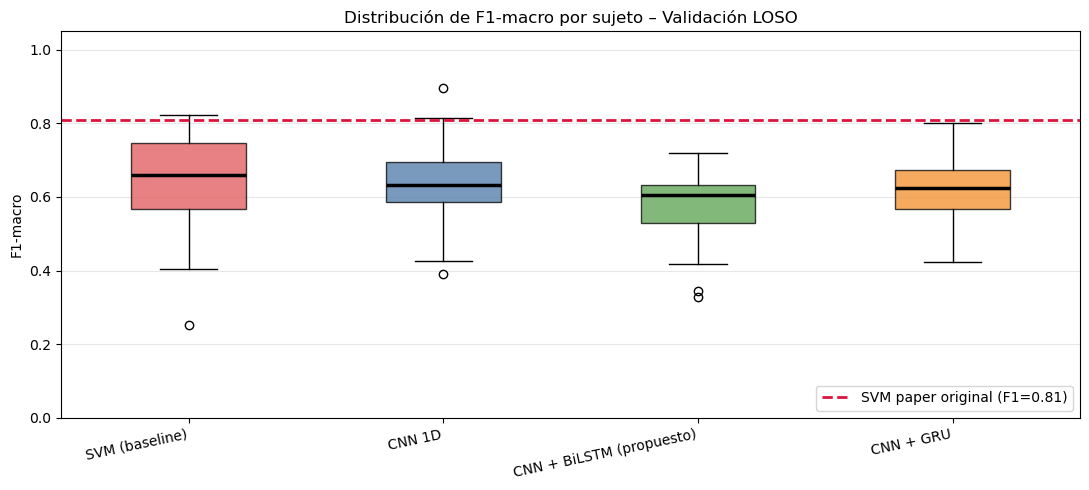

In [26]:
fig, ax = plt.subplots(figsize=(11, 5))

data_box, labels_box, colors_box = [], [], []
for key, res in all_results.items():
    data_box.append([r['f1_macro'] for r in res['per_subject']])
    labels_box.append(MODEL_LABELS[key])
    colors_box.append(MODEL_COLORS[key])

bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2.5))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.axhline(HARTH_PAPER['f1_macro'], color='crimson', linestyle='--',
           linewidth=2, label=f"SVM paper original (F1={HARTH_PAPER['f1_macro']})")

ax.set_xticks(range(1, 5))
ax.set_xticklabels(labels_box, rotation=12, ha='right')
ax.set_ylabel('F1-macro')
ax.set_ylim(0, 1.05)
ax.set_title('Distribución de F1-macro por sujeto – Validación LOSO')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('f1_boxplot.png', dpi=150)
plt.show()

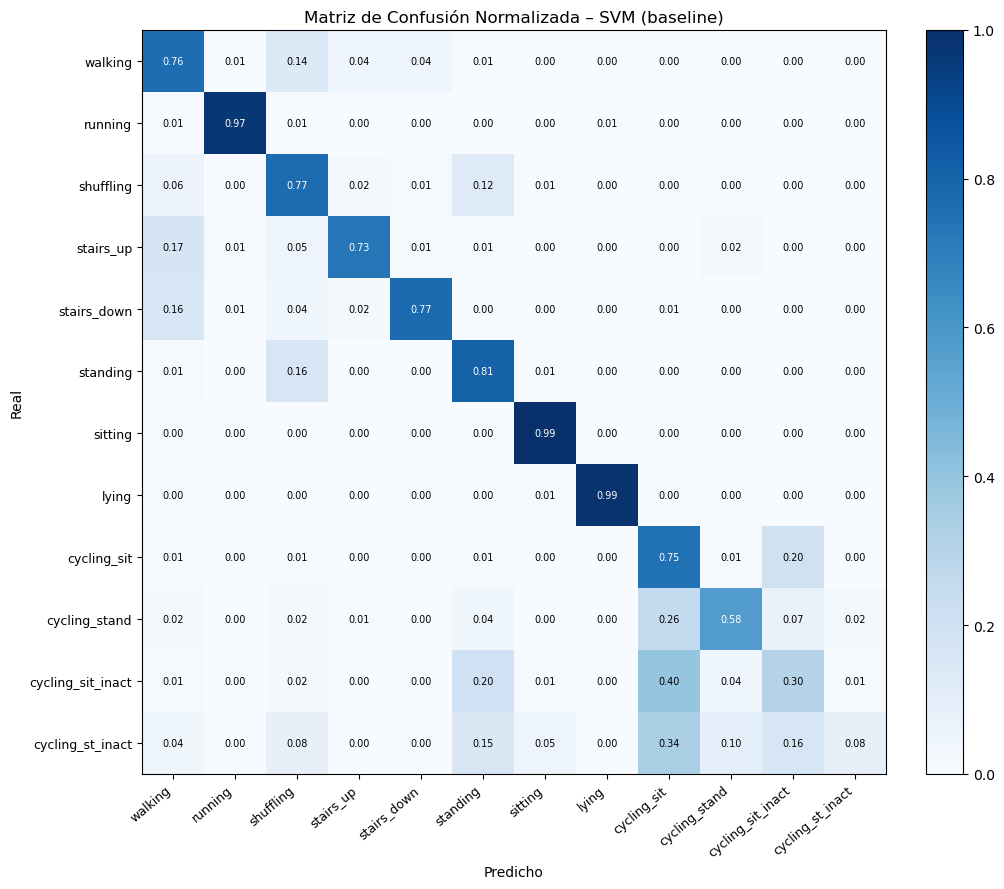

Mejor modelo: SVM (baseline)


In [27]:
best_key = max(all_results, key=lambda k: all_results[k]['mean_f1_macro'])
cm = np.array(all_results[best_key]['global_metrics']['conf_matrix'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
class_names = [IDX_TO_LABEL[i] for i in range(N_CLASSES)]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(class_names, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(class_names, fontsize=9)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        color = 'white' if cm_norm[i,j] > 0.5 else 'black'
        ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color=color)

ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión Normalizada – {MODEL_LABELS[best_key]}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(f'Mejor modelo: {MODEL_LABELS[best_key]}')

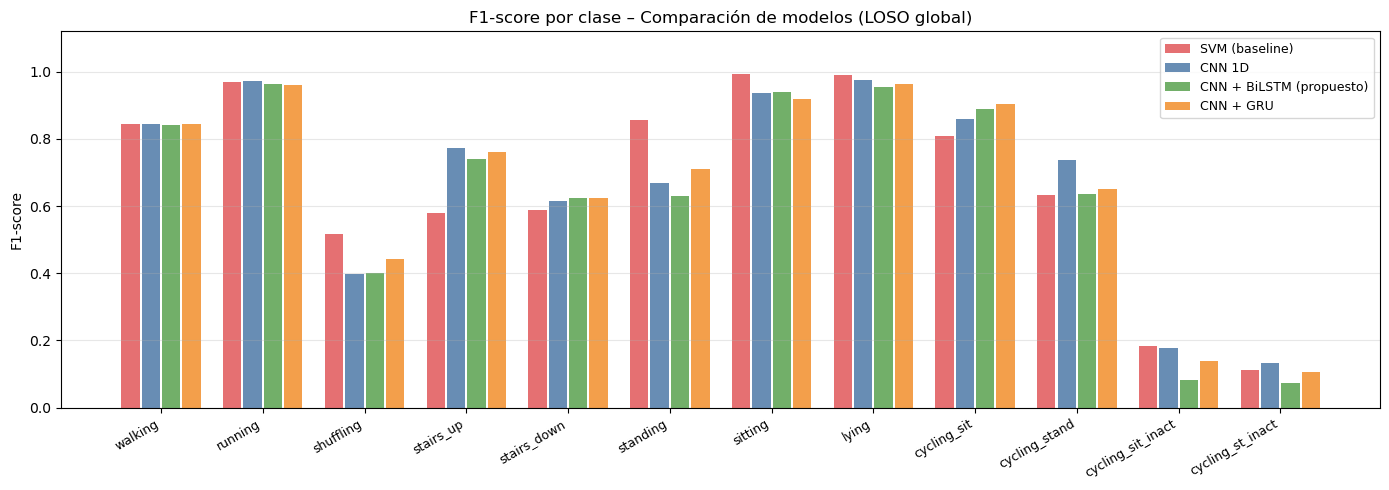

In [28]:
class_names = [IDX_TO_LABEL[i] for i in range(N_CLASSES)]
x = np.arange(N_CLASSES)
n_models = len(all_results)
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(14, 5))
for k, (key, res) in enumerate(all_results.items()):
    f1pc   = res['global_metrics']['f1_per_class']
    offset = (k - n_models/2 + 0.5) * width
    ax.bar(x + offset, f1pc, width * 0.9,
           label=MODEL_LABELS[key], color=MODEL_COLORS[key], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.12)
ax.set_title('F1-score por clase – Comparación de modelos (LOSO global)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150)
plt.show()

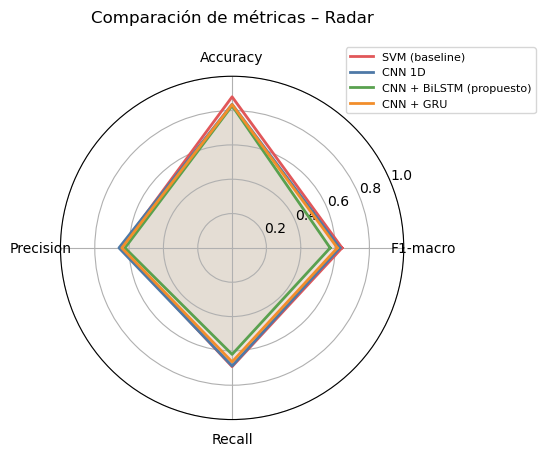

In [29]:
metric_keys   = ['mean_f1_macro', 'mean_accuracy', 'mean_precision', 'mean_recall']
metric_labels = ['F1-macro', 'Accuracy', 'Precision', 'Recall']
n_m = len(metric_keys)
angles = np.linspace(0, 2*np.pi, n_m, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for key, res in all_results.items():
    vals = [res.get(k, 0) for k in metric_keys] + [res.get(metric_keys[0], 0)]
    ax.plot(angles, vals, label=MODEL_LABELS[key],
            color=MODEL_COLORS[key], linewidth=2)
    ax.fill(angles, vals, alpha=0.07, color=MODEL_COLORS[key])

ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels)
ax.set_ylim(0, 1)
ax.set_title('Comparación de métricas – Radar', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig('radar_metrics.png', dpi=150)
plt.show()

In [30]:
# Serializar resultados a JSON (por si quieres retomar sin re-entrenar)
import json

for key, res in all_results.items():
    fname = f'results_{key}.json'
    # Convertir arrays numpy a listas para serialización
    def convert(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        raise TypeError
    with open(fname, 'w') as f:
        json.dump(res, f, indent=2, default=convert)
    print(f'  ✅ Guardado: {fname}')

print('\nArchivos generados en esta sesión:')
for fname in ['comparison_table.csv', 'f1_boxplot.png', 'confusion_matrix.png',
              'f1_per_class.png', 'radar_metrics.png',
              'results_svm.json', 'results_cnn1d.json',
              'results_cnn_bilstm.json', 'results_cnn_gru.json']:
    exists = '✅' if Path(fname).exists() else '❌'
    print(f'  {exists} {fname}')

  ✅ Guardado: results_svm.json
  ✅ Guardado: results_cnn1d.json
  ✅ Guardado: results_cnn_bilstm.json
  ✅ Guardado: results_cnn_gru.json

Archivos generados en esta sesión:
  ✅ comparison_table.csv
  ✅ f1_boxplot.png
  ✅ confusion_matrix.png
  ✅ f1_per_class.png
  ✅ radar_metrics.png
  ✅ results_svm.json
  ✅ results_cnn1d.json
  ✅ results_cnn_bilstm.json
  ✅ results_cnn_gru.json
